# Práctica 3 (complementaria) - Inteligencia Artificial

## Tema 1: Metaheurísticas para optimización

### Algoritmos genéticos

Miguel A. Gutérrez Naranjo

La Gioconda es un óleo sobre tabla de álamo de 77 × 53 cm, pintado entre 1503 y 1519 por Leonardo da Vinci. En esta práctica vamos a usar algoritmos genéticos para aproximar la siguiente imagen mediante rectángulos en escala de grises.

<img src="gioconda.jpg">

En primer lugar cargamos las bibliotecas que vamos a necesitar.

In [15]:
# Es posible que no todas estén instaladas. Puede ser necesario reiniciar el kernel tras la instalación
# !pip install imageio
# !pip install scikit-image

# 1.- numpy para la representación matricial
import numpy as np

# 2.- random para generar valores aleatorios
import random

# 3.- PIL e imageio para leer y escribir imágenes.
from PIL import Image
import imageio

# 4.- matplotlib para visualizar imágenes y gráficos.
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['figure.figsize'] = (15,10) # Para el tamaño de la imagen


# 5.- skimage para comparar imágenes.
from skimage.metrics import structural_similarity as ssim

#### De *jpg* a *array* de píxeles en escala de grises

Para empezar, tomamos la imagen que queremos aproximar desde un fichero (en este caso el fichero *gioconda.jpg*) y lo guardamos como una imagen python en escala de grises de 8-bits (256 valores). Para ello usamos las funcionalidades que proporciona la clase `Image` importado de la biblioteca PIL . Para más información consultar: https://pillow.readthedocs.io/en/stable/handbook/concepts.html

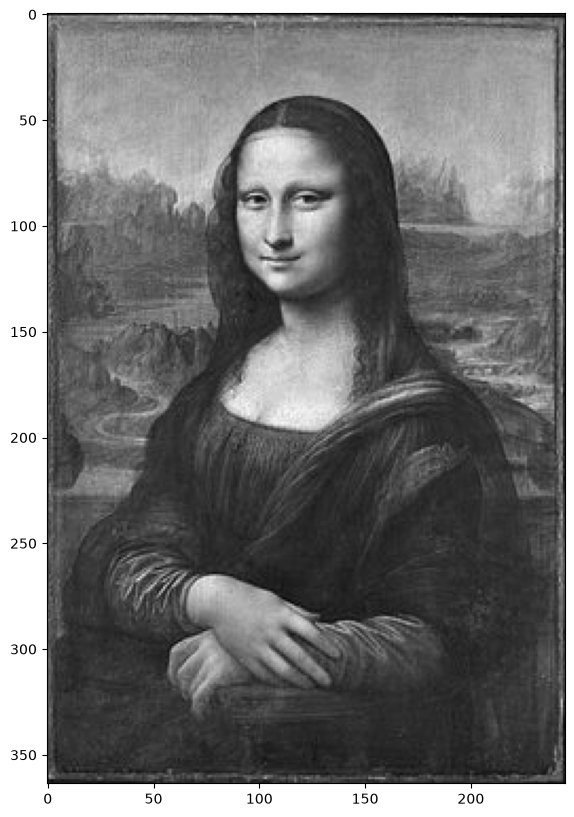

In [16]:
imagen_original = 'gioconda.jpg'
imagen_grises = Image.open(imagen_original).convert('L')
plt.imshow(imagen_grises,cmap='gray')

A continuación, transformamos la imagen en una matriz de valores comprendidos entre 0 y 255 mediante la biblioteca `numpy`. Es importante saber que al cambiar el tipo de dato de imagen a matriz se cambian los ejes https://stackoverflow.com/questions/33725237/image-fromarray-changes-size. Llamamos `IM2ARRAY` a la matriz que guarda las intensidades de gris de los píxeles.

In [17]:
IM2ARRAY = np.array(imagen_grises)
IM2ARRAY

array([[ 22,  47,  38, ...,  28,  34,  34],
       [ 87, 131,  97, ...,  26,  31,  20],
       [113, 117,  77, ...,  79,  79,  54],
       ...,
       [ 42, 102,  93, ...,  83,  77,  31],
       [ 16,  31,  17, ...,  69,  64,  31],
       [ 38,  33,  24, ...,  35,  35,  18]], shape=(364, 245), dtype=uint8)

Guardamos el tamaño de la matriz en la variable `im2array_shape` para usarlo como referencia al crear otras matrices.

In [18]:
im2array_shape = IM2ARRAY.shape
im2array_shape

(364, 245)

A continuación fijamos los parámetros del algoritmo genético y demás elementos necesarios que definiremos a continuación con el objetivo de aproximar la imagen anterior usando $150$ rectángulos, que pueden solaparse entre sí, en escala de grises.

In [19]:
# La longitud de los cromosomas
LONGITUD_CROMOSOMA = 150

# Tamaño de la población
TAMANO_POB = 500

# Número de cromosomas que intervienen en cada torneo
NUM_PARTICIPANTES = 50

# Probabilidad de mutación
PROB_MUTACION = 0.1

# Proporción de una generación que se usa como padres
PROP_PADRES = 0.5

# Número de generaciones
GENERACIONES = 10001

# Paso de impresión. Crearemos la imagen correspondiente al mejor cromosoma después de PASO_IMP generaciones
PASO_IMP = 100

#### Representación del problema

Usaremos una representación muy básica y se espera que, tras realizar la práctica, el/la estudiante sea capaz de probar con otros polígonos y pasar de la escala de grises a imágenes en color. También es interesante buscar otras definiciones de la función decodifica, que permite generar la imagen a partir del cromosoma, otras funciones *fitness* y otros algoritmos genéticos. 

Para la representación consideraremos que un gen será una tupla de números naturales $(x,y,dx,dy,c)$ que interpretaremos como un rectángulo con extremo superior izquierda $(x,y)$, lados $dx$ y $dy$ y $c\in \{0,1,\dots,255\}$ representa su color (en escala de grises).

### Ejercicio 1
Definir una función `genera_gen()` que, a partir de la variable `im2array_shape`, devuelva una tupla `(x,y,dx,dy,c)`. Hay que tener en cuenta que, fijado el extremo, el rectángulo esté dentro del lienzo y que el color esté en el rango 0-255.

In [20]:
# Solución
def genera_gen():
    x, y = random.randrange(im2array_shape[0]),random.randrange(im2array_shape[1])
    dx, dy = random.randrange(im2array_shape[0]-x), random.randrange(im2array_shape[1]-y)
    c = random.randrange(255)
    return (x,y,dx,dy,c) 

In [21]:
# Puedes probar la función
genera_gen()

# Posible respuesta:
# (185, 223, 49, 16, 2)

(135, 209, 155, 12, 146)

### Ejercicio 2
Definir una función `genera_cromosoma_()` que devuelva una tupla con tantos genes como determine el parámetro `LONGITUD_CROMOSOMA`

In [22]:
# Solución
def genera_cromosoma_():
    return tuple(genera_gen() for _ in range(LONGITUD_CROMOSOMA))

In [23]:
# Ejemplo de uso. Guardamos el cromosoma generado en la variable ind_1
ind_1 = genera_cromosoma_()
ind_1[:10], len(ind_1)

(((238, 118, 5, 76, 234),
  (0, 167, 197, 42, 238),
  (158, 47, 10, 80, 64),
  (333, 165, 30, 68, 176),
  (226, 25, 125, 20, 193),
  (96, 206, 54, 7, 135),
  (76, 107, 132, 50, 220),
  (357, 210, 2, 4, 149),
  (109, 113, 242, 122, 134),
  (221, 30, 26, 45, 62)),
 150)

Nótese que estamos representando una imagen con cerca de $90$ mil píxeles usando únicamente $750$ datos.

In [24]:
im2array_shape[0] * im2array_shape[1], LONGITUD_CROMOSOMA*5

(89180, 750)

Para poder interpretar un cromosoma como una imagen, primero generamos una matriz (array) a partir de ese listado de genes. En este caso, las posiciones que no están ocupadas por ningún cuadrado las interpretamos como blanco (valor 255) y en el resto de la posiciones se sumará la intensidad de los rectángulos que las ocupan. La función `decodifica` siguiente crea una matriz con la intensidad de gris de cada píxel a partir de un cromosoma.

In [25]:
def decodifica(ind):
    array_sal = np.zeros(im2array_shape,dtype='uint32')
    array_255 = np.full(im2array_shape,255,dtype='uint32')   
    for (x,y,dx,dy,c) in ind:
        array_sal[x:x+dx,y:y+dy]+= 255 - c
    mini = np.minimum(array_sal,array_255)
    inversa = 255 - mini
    return inversa

Podemos ver la matriz generada a partir del cromosoma que hemos creado.

In [26]:
matriz_1 = decodifica(ind_1)
matriz_1

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ...,  40, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(364, 245), dtype=uint32)

Y la imagen correspondiente a ese cromosoma transformando previamente la matriz. La comparamos con la imagen de la Gioconda en escala de grises.

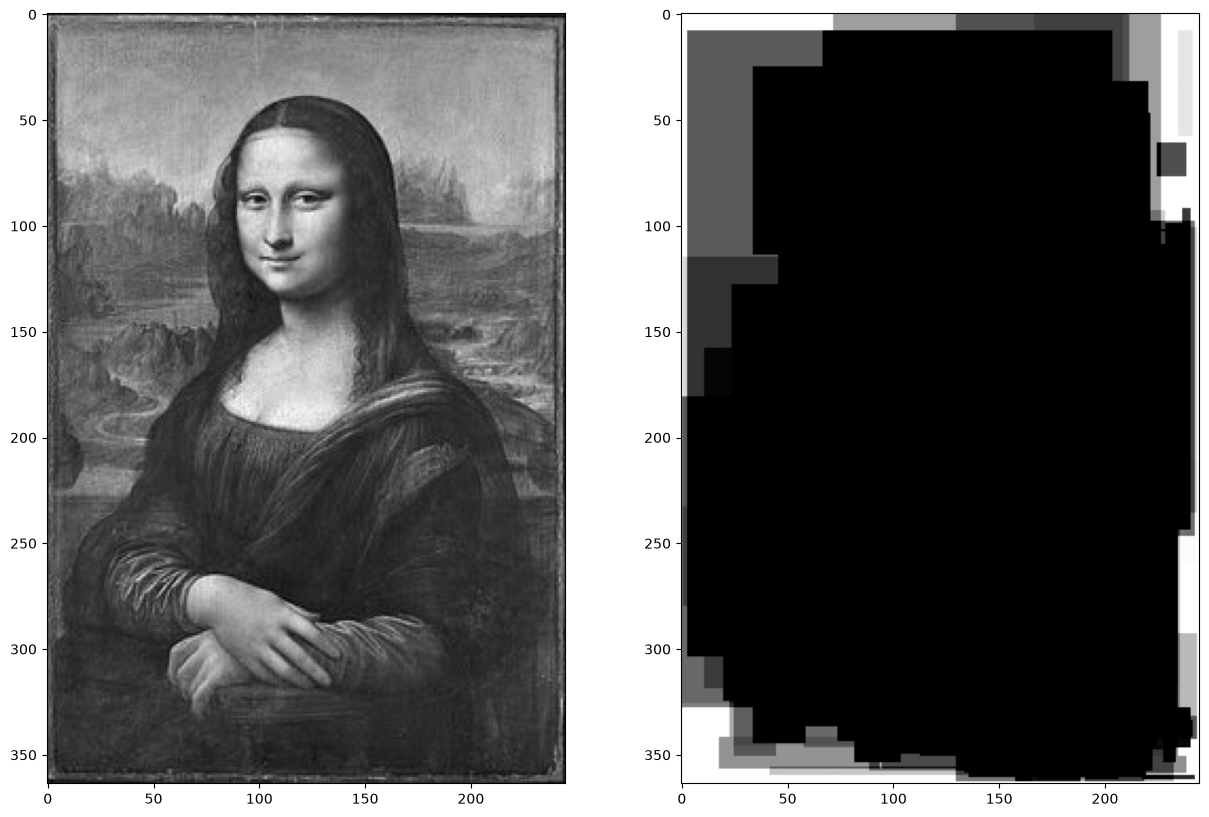

In [27]:
img_1 = Image.fromarray(matriz_1.astype('uint8'))

f, axarr = plt.subplots(1,2)
axarr[0].imshow(imagen_grises,cmap='gray')
axarr[1].imshow(img_1,cmap='gray')

Obviamente, este cromosoma es una mala aproximación de la imagen original. Vamos a implementar un algoritmo genético que permita encontrar una mejor. 

#### Algoritmo genético

En primer lugar definimos una función que nos permita crear una población inicial de cromosomas.

### Ejercicio 3
Define una función `poblacion_inicial()` que devuelva una lista con tantos cromosomas como determine la variable `TAMANO_POB`

In [28]:
# Solución
def poblacion_inicial():
    return [genera_cromosoma() for _ in range(TAMANO_POB)]

Para poder seleccionar los mejores individuos de una generación, necesitamos definir una *función fitness*. En este caso se define como la suma de las diferencias (en valor absoluto) pixel a pixel entre la matriz que representa el cromosoma y la matriz que representa la imagen original.

In [29]:
def fitness1(ind):
    return np.sum(np.absolute(decodifica(ind) - IM2ARRAY))

In [30]:
# Ejemplo:
fitness1(ind_1) / 1e14

np.float64(3.39714728481731)

A continuación implementamos la selección por torneo. Para evitar repetir cálculos, cuando calculemos el fitness de un cromosoma, lo guardaremos en un diccionario y miraremos si ya ha sido calculado antes cuando necesitemos saber su valor. Las claves del diccionario serán los cromosomas y su valor, el valor de fitness que le corresponda.

### Ejercicio 4
Definir una función `torneo(generacion,dic,fit)` que tome como entrada una generación de cromosomas, un diccionario de pares `cromosoma:fitness` y una función fitness, y devuelva una tupla `(seleccionado,nuevo_dic)` donde `seleccionado` sea un cromosoma de la generación seleccionado por torneo entre `NUM_PARTICIPANTES` participantes y `nuevo_dic` sea el diccionario `dic` al que se le han añadido los pares `cromosoma:fitness` que se hayan calculado en la búsqueda de `seleccionado`.

In [ ]:
# Solución
def torneo(generacion, dic, fit):
    
    return seleccionado, dic

In [78]:
# Ejemplo de uso
dic = {}
seleccionado_dic = torneo(poblacion_inicial(), dic, fitness1)
seleccionado_dic[1] == dic

True

### Ejercicio 5
Definir una función `selecciona_torneo(generacion, n, dic, fit)` que, además de los parámetros de la función anterior, reciba el número de cromosomas que queremos seleccionar. La salida debe ser una tupla *(seleccion,nuevo_dic)* donde `nuevo_dic` es el diccionario actualizado tras los `n`torneos y `seleccion` es una lista con los cromosomas seleccionados. 

In [ ]:
# Solución
def selecciona_torneo(generacion, n, dic, fit):
    pass

In [80]:
# Ejemplo de uso
dic = {}
seleccion_dic = selecciona_torneo(poblacion_inicial(), 4, dic, fitness1)
seleccion_dic[1] == dic

True

A continuación definimos el cruce entre cromosomas

### Ejercicio 6
Definir una función `cruza_padres(c1,c2)` que tome dos cromosomas y devuelva una lista con los dos hijos obtenidos mediante la técnica de cruce en un punto.

In [ ]:
# Solución
def cruza_padres(c1, c2):
    pass

### Ejercicio 7
Definir una función `cruza(padres)` que tome como entrada una lista con un número par de cromosomas y devuelva la lista de hijos obtenida aplicando la función anterior a las sucesivas parejas de padres.

In [ ]:
# Solución
def cruza(padres):
    pass

### Ejercicio 8
Definir un par funciones `muta_cromosoma_i(ind)` que reciban como entrada un cromosoma. La primera debe obtener un nuevo cromosoma resultado de mutar cada gen con probabilidad `PROB_MUTACION`. La segunda, con probabilidad `PROB_MUTACION` mutará sólo uno de sus genes.

In [ ]:
# Solución
# Mutar cada gen con probabilidad PROB_MUTACION
def muta_cromosoma_1(ind):
    pass

# Mutar un sólo gen elegido al azar con probabilidad PROB_MUTACION
def muta_cromosoma_2(ind):
    pass

### Ejercicio 9
Definir una función `muta(generacion, mc)` que reciba como entrada la lista de cromosomas y una de las funciones anteriores, y devuelva el resultado de aplicarla a cada cromosoma de la lista.

In [ ]:
# Solución
def muta(generacion, mc):
    pass

A continuación definimos el algoritmo que permite encontrar una nueva generación a partir de una dada.

### Ejercicio 10
Definir una función `nueva_poblacion(generacion, n_padres, n_directos, dic, fit, mc)` que reciba como entrada:
* *generacion* es una población de cromosomas
* *n_padres* es un número que determina cuántos cromosomas seleccionar por torneo para ser padres
* *n_directos* es un número que determina cuántos cromosomas seleccionar por torneo para pasar directamente a la siguiente generación.
* *dic* es un diccionario de pares *cromosoma:fitness*
* *fit* una función fitness
* *mc* una función de mutación

La función debe seleccionar un conjunto de cromosomas para ser padres y otro para pasar directamente a la siguiente generación. A partir de los padres se debe generar un conjunto de hijos por cruce. La función debe devolver una tupla `(nueva_gen,nuevo_dic)` donde `nueva_gen` es una lista de cromosomas con los que pasan directamente más el resultado de aplicar la función de mutación a los hijos.

In [ ]:
# Solución
def nueva_poblacion(generacion, n_padres, n_directos, dic, fit, mc):
    pass

Por último definimos el algoritmo genético en el que se genera una población inicial y se van creando nuevas generaciones usando las funciones anteriores. Además, cada *PASO_IMP* imprimimos la imagen correspondiente al mejor cromosoma de esa generación. La función devuelve la lista de los valores *fitness* de estos cromosomas, para poder luego representar gráficamente la evolución de la función a lo largo de las `GENERACIONES`, y el último de ellos.

In [ ]:
def algoritmo_genetico(fit, mc):
    generacion = poblacion_inicial()
    dic = {}
    n_padres = round(TAMANO_POB * PROP_PADRES)
    n_padres = (n_padres if n_padres%2==0 else n_padres-1)
    n_directos = TAMANO_POB - n_padres
    val_mejores = []
    for counter in range(GENERACIONES):
        if counter%PASO_IMP == 0:
            print(counter)
            min = float('inf')
            for ind in generacion:
                if ind in dic:
                    f_ind = dic[ind]
                else:
                    f_ind = fit(ind)
                if f_ind < min:
                    mejor = ind
                    min = f_ind
            img_mejor = decodifica(mejor).astype('uint8')
            imageio.imwrite('ga_{:>08}.jpg'.format(counter//PASO_IMP),img_mejor)
            val_mejores.append(min)
        else:
            print('.',end='')
        generacion, dic = nueva_poblacion(generacion, n_padres, n_directos, dic, fit, mc)
    return val_mejores, mejor

In [ ]:
sal_ag1 = algoritmo_genetico(fitness1, muta_cromosoma_1)

0


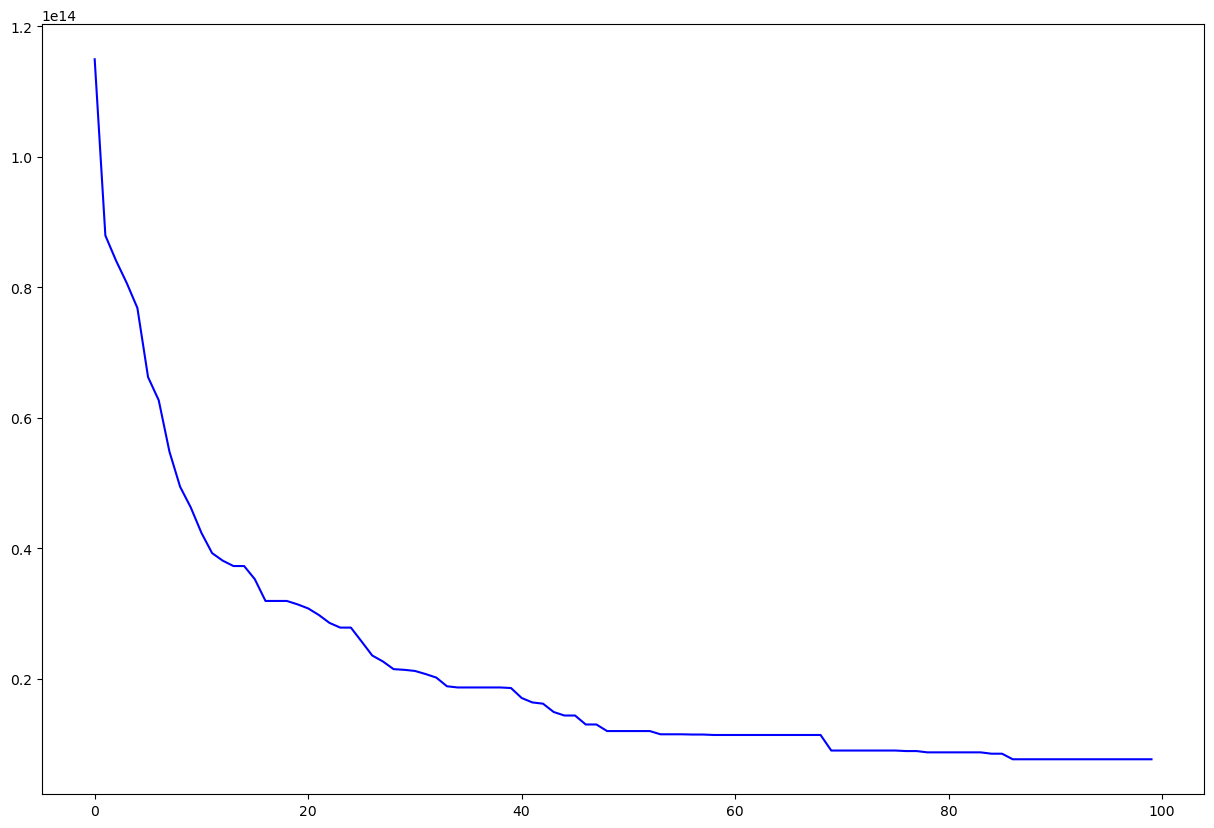

In [ ]:
plt.plot(sal_ag1[0][1:], color = "b")
plt.show()

In [ ]:
sal_ag2 = algoritmo_genetico(fitness1, muta_cromosoma_2)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000


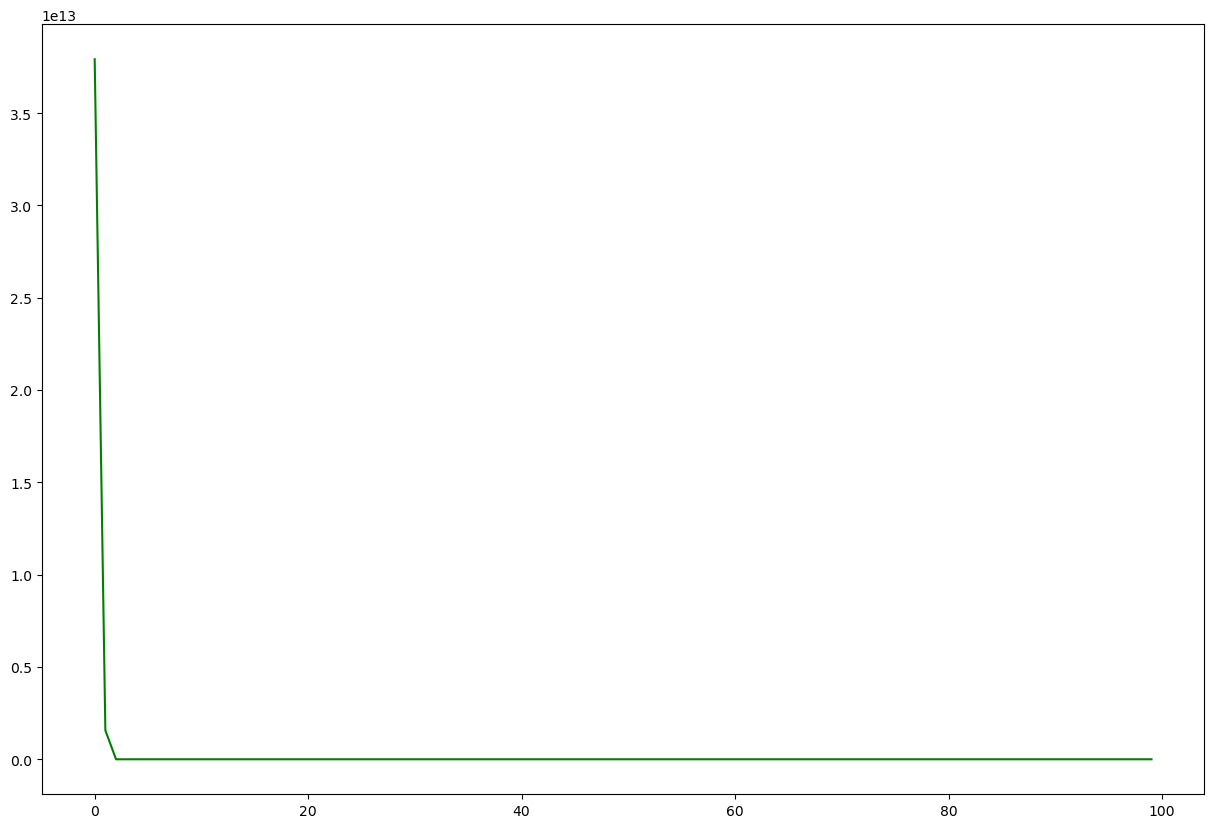

In [ ]:
plt.plot(sal_ag2[0][1:], color = "g")
plt.show()

In [168]:
sal_ag1[0][1], sal_ag1[0][-1], sal_ag2[0][1], sal_ag2[0][-1]

(91147803553825, 4157539849507, 81668812232985, 8169582)

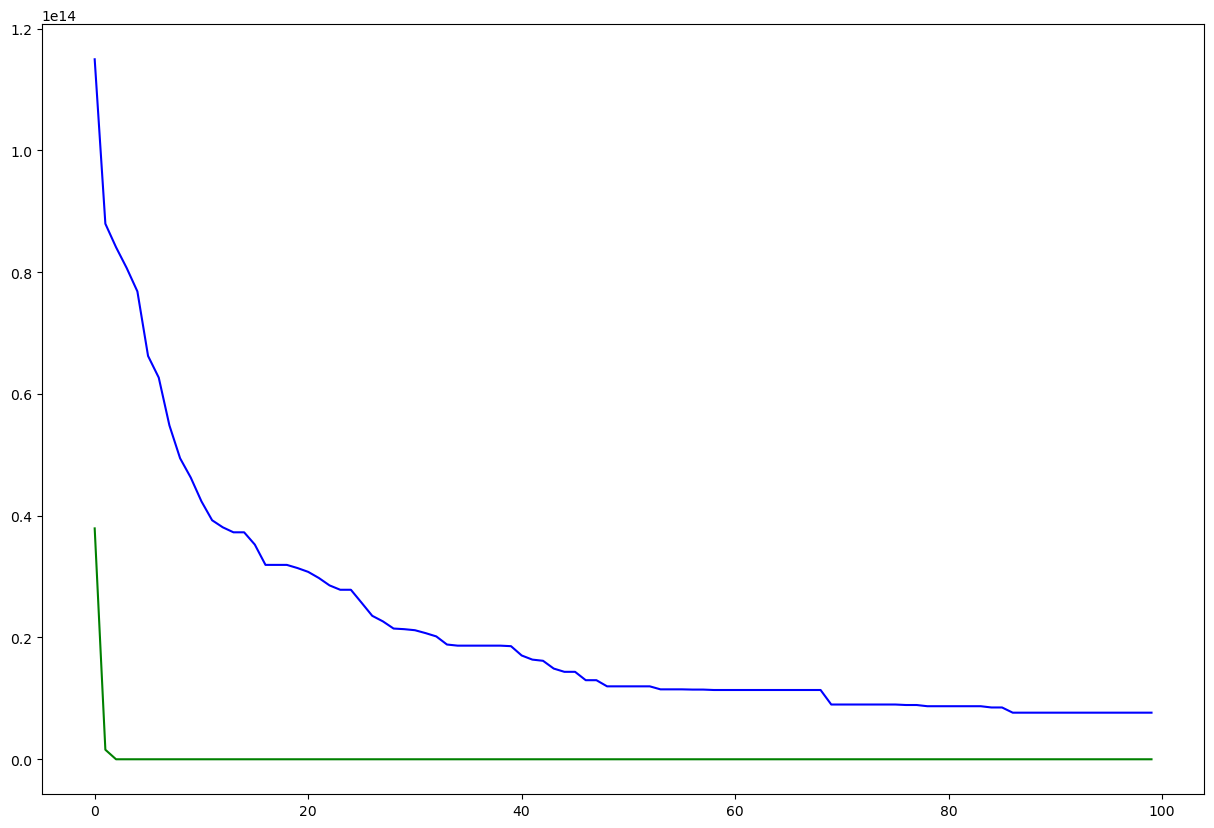

In [ ]:
plt.plot(sal_ag1[0][1:], color = "b")
plt.plot(sal_ag2[0][1:], color = "g")
plt.show()

### Ejercicio 11
La función fitness definida anteriormente es fácil de implementar, pero no es la más apropiada para comparar imágenes. Vamos a considerar otra medida basada en la similaridad estructural para comparar imágenes utilizando la función `structural_similarity` de la biblioteca `skimage.metrics` (importada como `ssim`). Para más información consultar: https://scikit-image.org/docs/0.25.x/api/skimage.metrics.html#skimage.metrics.structural_similarity

In [ ]:
def fitness2(ind):
    dec = decodifica(ind)
    return 1 - ssim(IM2ARRAY, dec, data_range=dec.max() - dec.min())

# Ejemplo:
fitness2(ind_1)

0.9878615912126089

In [ ]:
sal_ag3 = algoritmo_genetico(fitness2, muta_cromosoma_2)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000


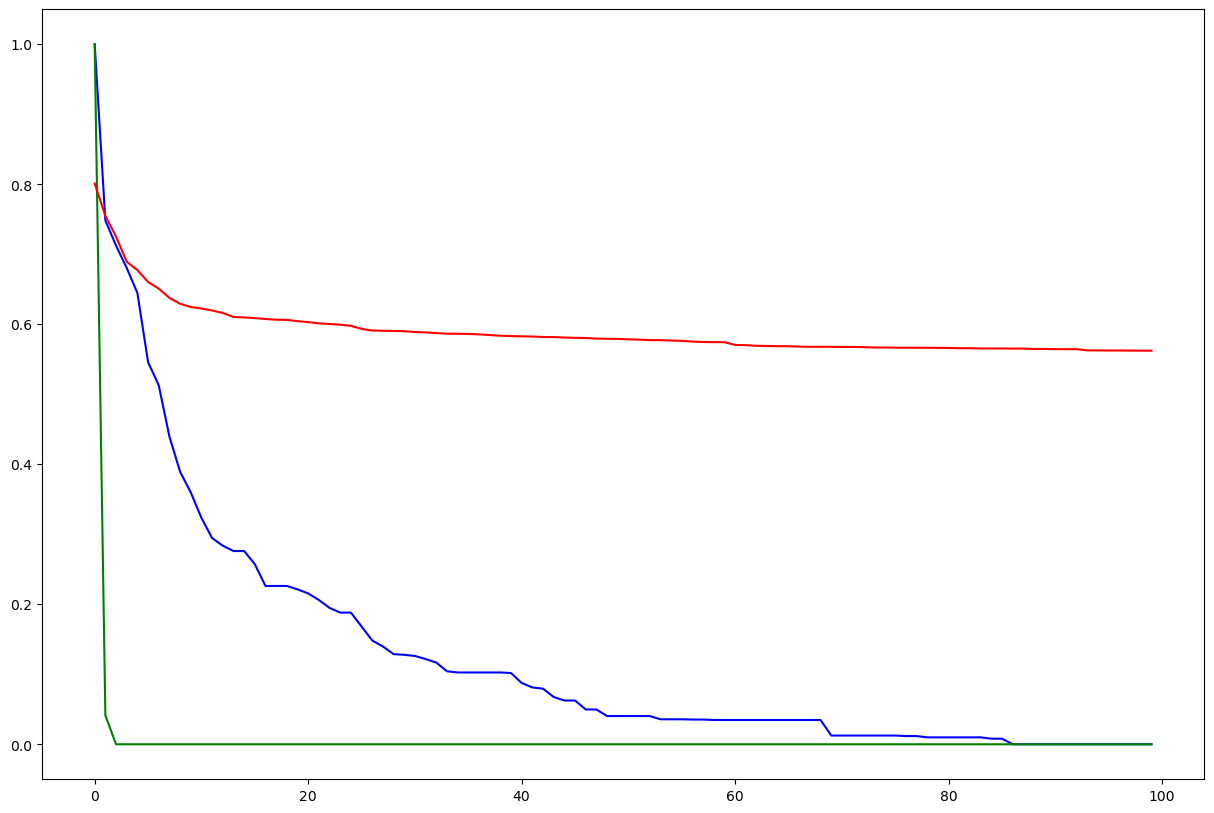

In [ ]:

M1 = max(sal_ag1[0][1:])
m1 = min(sal_ag1[0][1:])

M2 = max(sal_ag2[0][1:])
m2 = min(sal_ag2[0][1:])

plt.plot([(x - m1) / (M1 - m1) for x in sal_ag1[0][1:]], color = "b")
plt.plot([(x - m2) / (M2 - m2) for x in sal_ag2[0][1:]], color = "g")
plt.plot(sal_ag3[0][1:], color = "r")
plt.show()

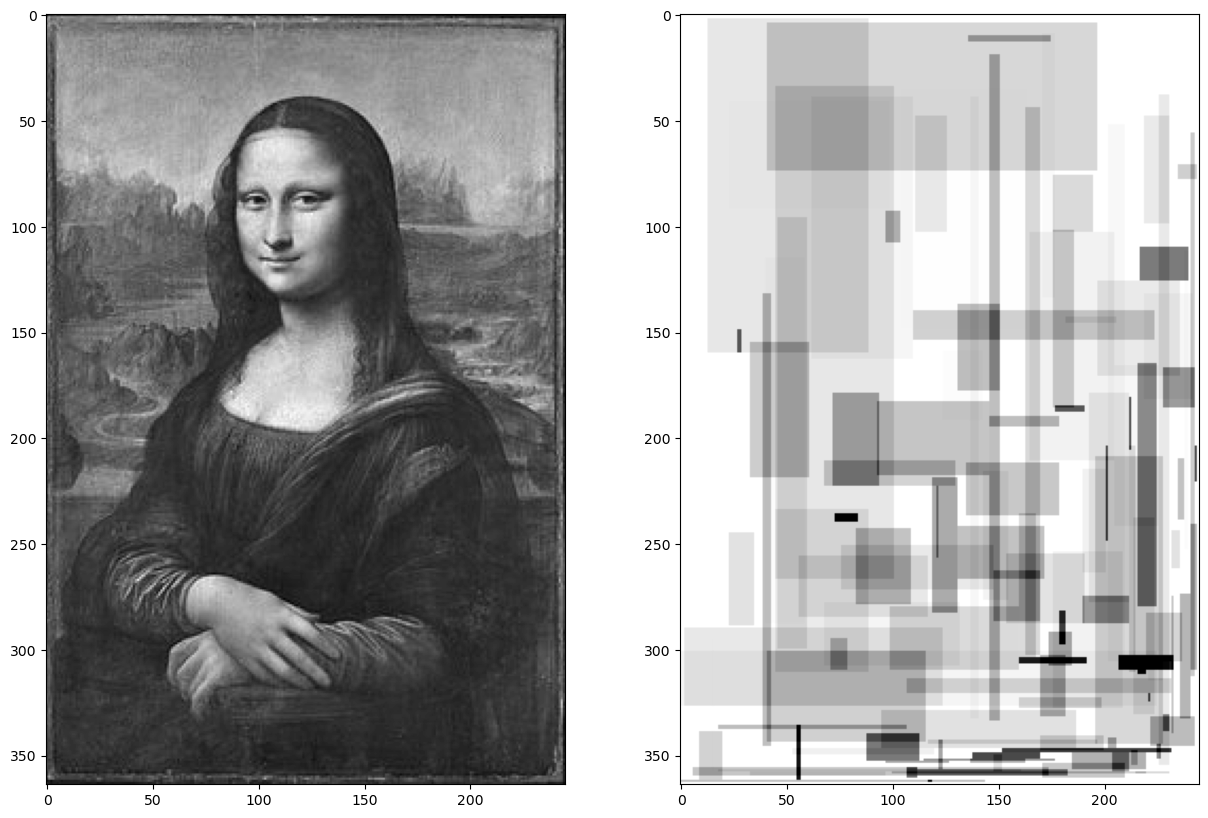

In [ ]:
indM1 = sal_ag1[1]
matrizM1 = decodifica(indM1)
imgM1 = Image.fromarray(matrizM1.astype('uint8'))

f, axarr = plt.subplots(1,2)
axarr[0].imshow(imagen_grises,cmap='gray')
axarr[1].imshow(imgM1,cmap='gray')

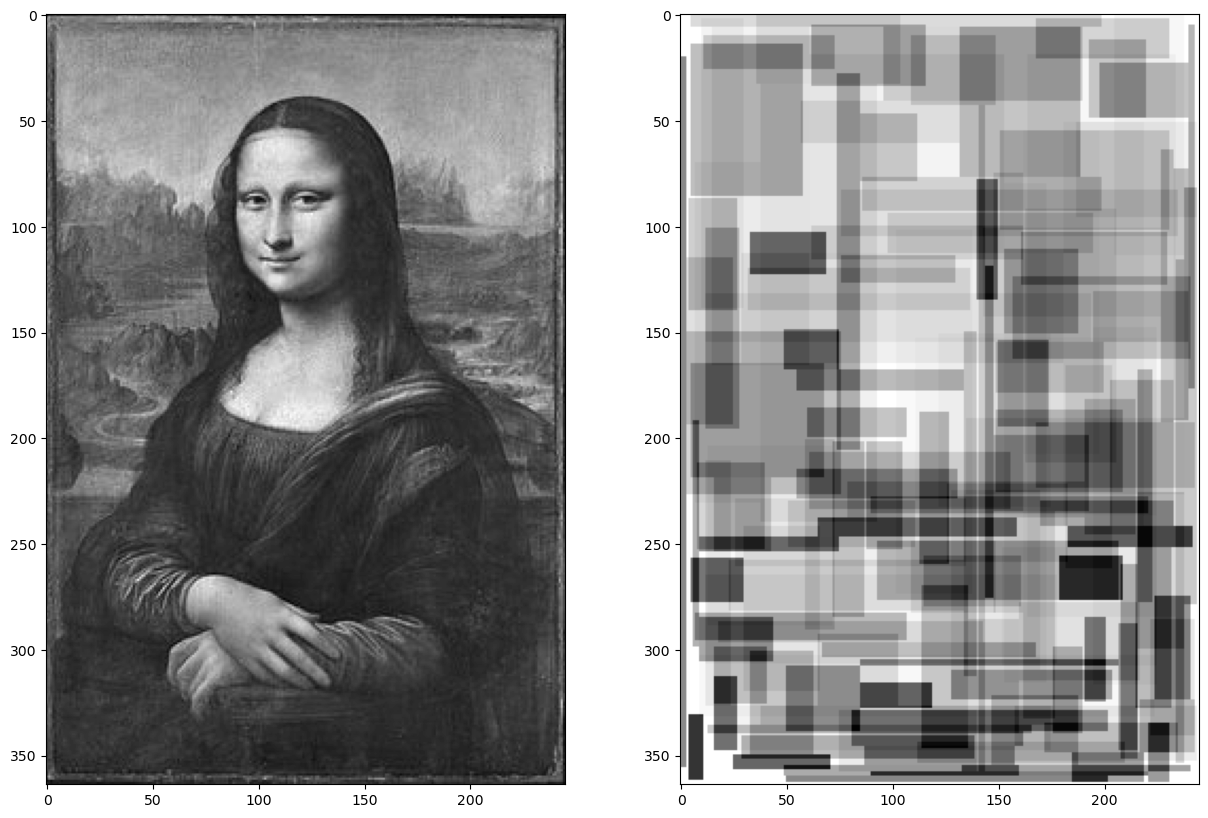

In [ ]:
indM2 = sal_ag2[1]
matrizM2 = decodifica(indM2)
imgM2 = Image.fromarray(matrizM2.astype('uint8'))

f, axarr = plt.subplots(1,2)
axarr[0].imshow(imagen_grises,cmap='gray')
axarr[1].imshow(imgM2,cmap='gray')

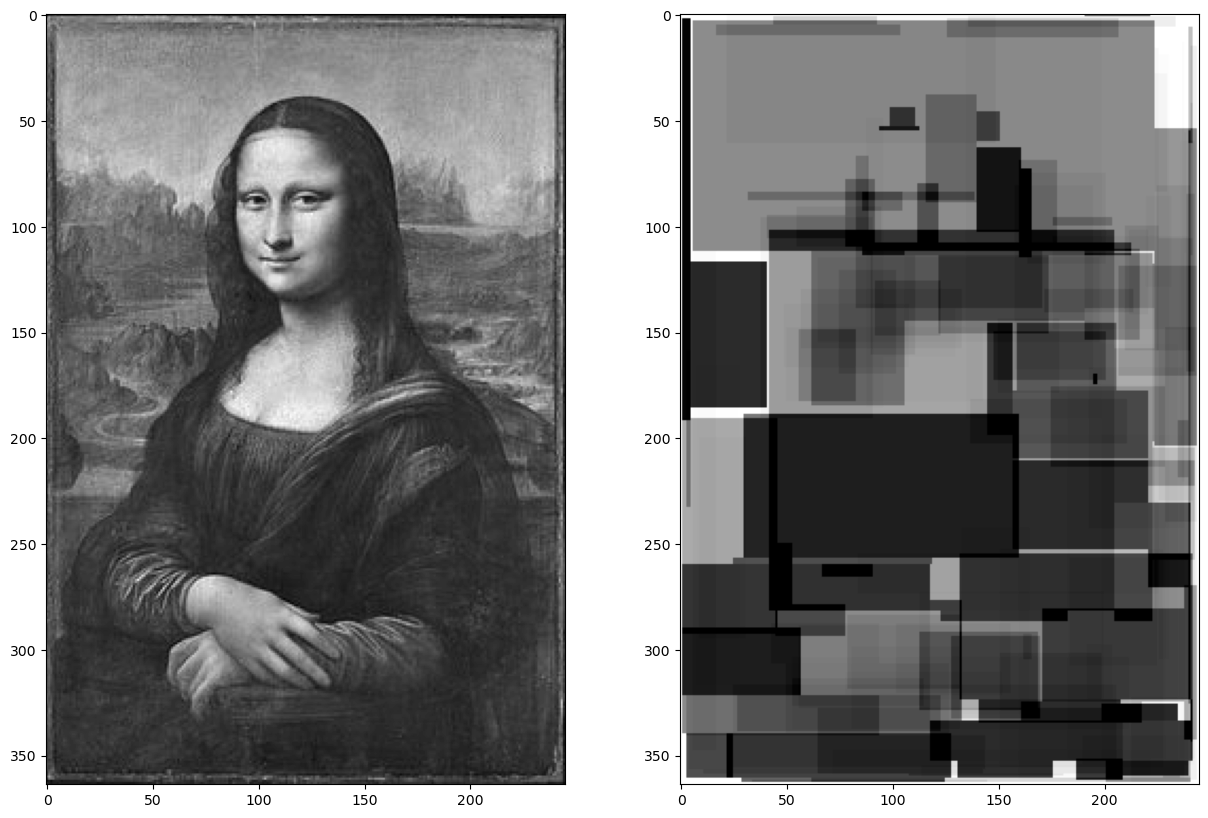

In [ ]:
indM3 = sal_ag3[1]
matrizM3 = decodifica(indM3)
imgM3 = Image.fromarray(matrizM3.astype('uint8'))

f, axarr = plt.subplots(1,2)
axarr[0].imshow(imagen_grises,cmap='gray')
axarr[1].imshow(imgM3,cmap='gray')

In [ ]:
fitness1(indM1) / 1e14 , fitness1(indM2) / 1e14 , fitness1(indM3) / 1e14, fitness2(indM1), fitness2(indM2) , fitness2(indM3)


(0.07653642944617,
 8.11393e-08,
 1.52415505455699,
 0.8067055019731366,
 0.8671795453266959,
 0.5622576060843517)